# Question 2

Question:
The provided equation we are minimizing along with the unconstrained problems, appears to create a unit circle as the boundary of the constraints.

a)
Two Constraints:
h1(x) = 1 - x_1^2 - x_2^2 >= 0
h2(x) = x_1 + x_2 >= 0

Rewritten:
h1(x) = x_1^2 + x_2^2 <= 1             
All points inside of on the circle of radius 1

h2(x) = x_1 + x_2 >= 0
The boundary of this is the line: x1 + x2 = 0  -> x_2 = -x_1

So the feasible set is:
inside the unit circle
on the side of the line where x_1 + x_2 >= 0

The optimizer will end up near a boundary, as to minimize the equation, we are looking for values where each sqaured (part) is as small as possible.
Say we took:
x_1 = 1 ; x_2 = 2 
then
f([1, 2]) = 0

however it violates the constraints:
1^2 + 2^2 = 5 > 1 

b)
When using the barrier method we:
1. Iterate while remaining inside the feasible set
2. Make it expensive to reach the boundary
3. Start penalizing less so the solution can reach the constrined optimum

We replace the inequality constrained problem:
minf(x)       ;        h_i(x) >= 0 
with the unconstrained sequence of barrier problems:
O_u(x) = f(x) - (mu)(SIGMA[log(h_i(x))])

When using the natural logarithmic barrier:
Ex: -log(h_i(x)) 
the log(x) only exists for x > 0, so -log(h_i(x)) is only defined when h_i(x) > 0, which gives us a way to strictly stay within the feasible set.
As h_i(x) approaches 0, it approaches -inf, so we ensure to apply a (-) to make it +inf.

We also apply a penalty parameter u (mew), which controls how strong the barrier is (higher = stronger), so our final equation becomes:
O_u(x) = f(x) - ulog(h_1(x)) - ulog(h_2(x))


Gradient:
Using:
$\nabla$[-(mu)log(h(x))] = -(mu)[$\nabla$[h(x)]/h(x)]

We get 
$\nabla$ = [
    2(x_1 - 1) + [2(mu)x_1]/h_1(x) - mu/h_2(x),
    4(x_2 - 2) + [2(mu)x_2]/h_1(x) - mu/h_2(x)
]


Hessian:
Using:
$\nabla$^2[-log(h(x))] = [$\nabla$ h(x) $\nabla$ h(x)^T]/(h(x)^2) - $\nabla$^2h(x)/h(x)
the hessian becomes:
$\nabla$^2O(x) = [2 0 | 0 4] + 2(mu)I_2/h1 + 4(mu)/(h_1)^2[x_1^2  (x_1)(x_2)  | (x_1)(x_2)  (x_2)^2] + [mu/(h_2)^2][1  1  |  1  1]


Outer Loop:
x(0) = [0.5  0.5]^T      (mu)_0 = 1     (mu)_k+1 = 1/2(mu_k)
where we stop when:
||x^(k+1) - x^k|| < 0.002

Our final solution is
x = [0.31144051 0.94841288]
And this point lies within the circle.

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

In [13]:
def f(x):
    x1, x2 = x
    return (x1 - 1)**2 + 2*(x2 - 2)**2

def h1(x):
    x1, x2 = x
    return 1 - x1**2 - x2**2

def h2(x):
    x1, x2 = x
    return x1 + x2

def barrier_obj(x, mu):
    """
    Barrier idea 
    O_u(x) = f(x) - ulog(h_1(x)) - ulog(h_2(x))
    """
    v1 = h1(x)
    v2 = h2(x)
    if v1 <= 0 or v2 <= 0:
        return np.inf
    return f(x) - mu*np.log(v1) - mu*np.log(v2)

def barrier_grad(x, mu):
    """
    We compute the gradient
    """
    x1, x2 = x
    v1 = h1(x)
    v2 = h2(x)

    return np.array([
        2*(x1 - 1) + 2*mu*x1/v1 - mu/v2,
        4*(x2 - 2) + 2*mu*x2/v1 - mu/v2
    ], dtype=float)

def barrier_hess(x, mu):
    """
    We also compute the Hessian of the barrier objective.
    This helps the inner solver move more reliably.
    """
    x1, x2 = x
    v1 = h1(x)  
    v2 = h2(x)

    # Hessian of the original objective
    Hf = np.array([[2, 0], [0, 4]], dtype=float)

    # Hessian from -mu log(h1), where h1 = 1 - x1^2 - x2^2
    H_log_h1 = (2*mu*np.eye(2)/v1 + 4*mu*np.array([[x1*x1, x1*x2], [x1*x2, x2*x2]], dtype=float)/(v1**2))

    # Hessian from -mu log(h2), where h2 = x1 + x2
    H_log_h2 = mu*np.ones((2, 2), dtype=float)/(v2**2)

    return Hf + H_log_h1 + H_log_h2


def solve_barrier_subproblem(x0, mu):
    """
    For each fixed mu, solve the unconstrained barrier subproblem.
    """
    result = opt.minimize(
        fun=lambda x: barrier_obj(x, mu),
        x0=x0,
        method="trust-constr",
        jac=lambda x: barrier_grad(x, mu),
        hess=lambda x: barrier_hess(x, mu),
        options={"gtol": 1e-12, "xtol": 1e-12, "maxiter": 1000}
    )
    return result


#### Part a)

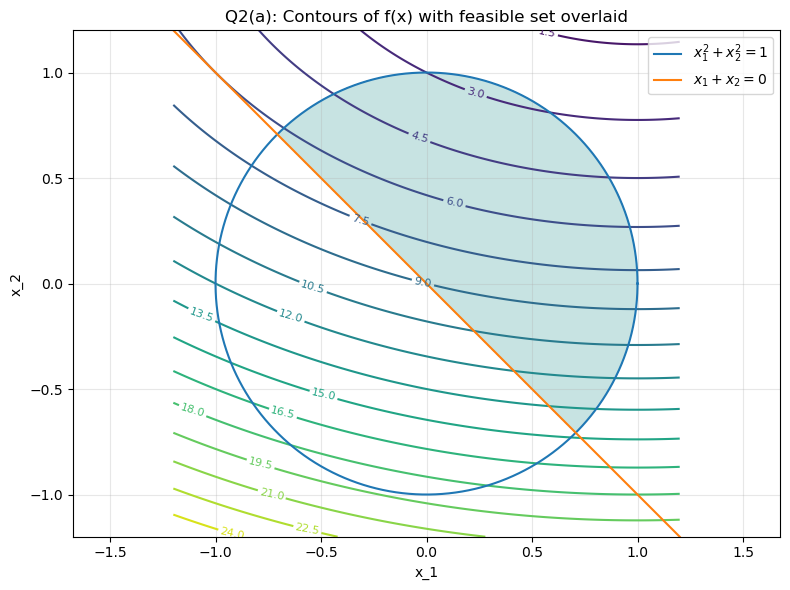

In [4]:
x1_vals = np.linspace(-1.2, 1.2, 500)
x2_vals = np.linspace(-1.2, 1.2, 500)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

F = (X1 - 1)**2 + 2*(X2 - 2)**2
feasible = ((1 - X1**2 - X2**2) >= 0) & ((X1 + X2) >= 0)

plt.figure(figsize=(8, 6))
contour = plt.contour(X1, X2, F, levels=20)
plt.clabel(contour, inline=True, fontsize=8)

# Overlay feasible set
plt.contourf(X1, X2, feasible.astype(int), levels=[0.5, 1.5], alpha=0.25)

# Draw boundaries
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), label=r"$x_1^2 + x_2^2 = 1$")
plt.plot(x1_vals, -x1_vals, label=r"$x_1 + x_2 = 0$")

plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("Q2(a): Contours of f(x) with feasible set overlaid")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Part b)

In [ ]:
x = np.array([0.5, 0.5], dtype=float)
mu = 1.0
tol = 0.002

trajectory = [x.copy()]
outer_iter = 0

print("\nBarrier iterations:")
while True:
    result = solve_barrier_subproblem(x, mu)
    x_new = result.x

    print(f"Outer iter {outer_iter:2d}: mu = {mu:.6f}, x = {x_new}, f(x) = {f(x_new):.8f}")

    trajectory.append(x_new.copy())

    # Problem says use stopping threshold 0.002
    if np.linalg.norm(x_new - x) < tol:
        x = x_new
        break

    x = x_new
    mu *= 0.5
    outer_iter += 1

print("\nPart (b) final barrier solution =", x)
print("Objective value =", f(x))
print("h1(x) =", h1(x))
print("h2(x) =", h2(x))


Barrier iterations:
Outer iter  0: mu = 1.000000, x = [0.3138451  0.79112189], f(x) = 3.39358112
Outer iter  1: mu = 0.500000, x = [0.309619   0.85617931], f(x) = 3.09327744
Outer iter  2: mu = 0.250000, x = [0.30928392 0.89832601], f(x) = 2.90445987
Outer iter  3: mu = 0.125000, x = [0.30998762 0.92281909], f(x) = 2.79675451
Outer iter  4: mu = 0.062500, x = [0.31065061 0.9361192 ], f(x) = 2.73888729
Outer iter  5: mu = 0.031250, x = [0.31107594 0.94306512], f(x) = 2.70883904
Outer iter  6: mu = 0.015625, x = [0.31131446 0.94661676], f(x) = 2.69352029
Outer iter  7: mu = 0.007812, x = [0.31144051 0.94841288], f(x) = 2.68578510

Part (b) final barrier solution = [0.31144051 0.94841288]
Objective value = 2.6857850971021873
h1(x) = 0.0035178105323404596
h2(x) = 1.259853395090171


#### Part c)    

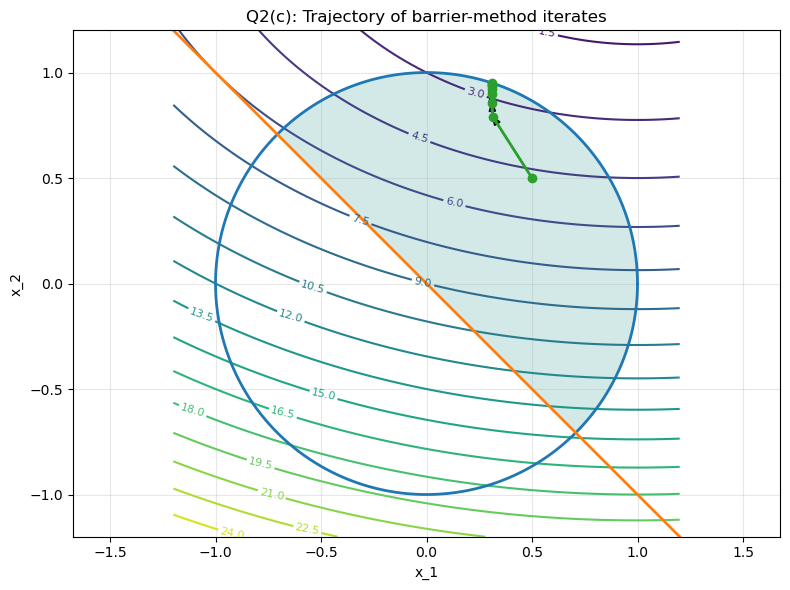

In [16]:
trajectory = np.array(trajectory)

plt.figure(figsize=(8, 6))
contour = plt.contour(X1, X2, F, levels=20)
plt.clabel(contour, inline=True, fontsize=8)
plt.contourf(X1, X2, feasible.astype(int), levels=[0.5, 1.5], alpha=0.20)

plt.plot(np.cos(theta), np.sin(theta), linewidth=2)
plt.plot(x1_vals, -x1_vals, linewidth=2)

plt.plot(trajectory[:, 0], trajectory[:, 1], marker="o", linewidth=2)

# Draw arrows so the movement is visible
for i in range(len(trajectory) - 1):
    dx = trajectory[i + 1, 0] - trajectory[i, 0]
    dy = trajectory[i + 1, 1] - trajectory[i, 1]
    plt.arrow(
        trajectory[i, 0], trajectory[i, 1],
        dx, dy,
        head_width=0.03, head_length=0.04,
        length_includes_head=True
    )

plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("Q2(c): Trajectory of barrier-method iterates")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q2_trajectory.png", dpi=200)
plt.show()